# تشغيل النوتبوك على Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nada-Elghaweet/Speaker_Diarization/blob/abdulla/f33_annotated_arabic_story.ipynb)

> **مهم:** بعد فتح النوتبوك على Colab اختار:
>
> `Runtime → Change runtime type → GPU`
>
> هذا مهم لأن HuBERT و Whisper models أسرع بكثير على GPU.

لو اسم الريبو أو مكان النوتبوك مختلف، غيّر رابط الزر إلى الشكل ده:

```text
https://colab.research.google.com/github/Nada-Elghaweet/Speaker_Diarization/blob/abdulla/f33_annotated_arabic_story.ipynb
```


## GitHub / Colab save instructions

بعد تشغيل أو تعديل النوتبوك داخل Google Colab:

1. افتح من القائمة: `File → Save a copy in GitHub`
2. اختار repository: `Nada-Elghaweet/Speaker_Diarization`
3. اختار branch: `abdulla`
4. خلي اسم الملف: `f33_annotated_arabic_story.ipynb`
5. اكتب commit message واضح، مثل: `update Abdulla notebook`
6. اضغط OK / Save

> ملاحظة: لازم يكون عندك permission على الريبو أو تكوني عاملة fork/branch عندك صلاحية تكتب عليه.


In [ ]:
# Colab quick setup - شغّل هذه الخلية عند التشغيل على Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Colab is ready. Make sure GPU is enabled from Runtime > Change runtime type > GPU')
else:
    print('Not running on Colab. You can skip this cell locally.')


# 📌 Story / شرح عربي قبل البداية

النوتبوك ده معمول كجزء من مشروع **Speaker-Aware Transcription**، يعني مش مجرد تحويل الصوت إلى نص، لكن كمان نحاول نربط كل جزء من الكلام بالـ speaker/channel الخاص به.

الفكرة العامة:

```text
AMI Meeting Audio
        ↓
تقسيم الصوت إلى Segments
        ↓
استخراج Speech Embeddings باستخدام HuBERT
        ↓
تجميع/اختبار تمثيل المتحدثين باستخدام KMeans
        ↓
تحويل كل segment إلى نص باستخدام Whisper
        ↓
Speaker-Aware Transcript
```

**ملاحظة مهمة للعرض أو GitHub:** هنا إحنا لا نقوم بتدريب HuBERT أو Whisper من الصفر. إحنا بنستخدمهم كـ pretrained models:

- **HuBERT** لاستخراج features/embeddings قوية من الصوت.
- **Whisper** لتحويل الصوت إلى نص Speech-to-Text.



# Speaker-Aware Transcription using Pretrained HuBERT + Pretrained Transformer

## My part in the team project

This notebook is for the **pretrained models part** of the project.

The team idea can be divided like this:

| Part | Idea | Main Models |
|---|---|---|
| Friend X | Build everything from scratch | Log-Mel features + CNN from scratch + Transformer from scratch |
| Friend Y | Pretrained speech features + trainable model | Pretrained HuBERT + Transformer classifier from scratch |
| **This notebook** | Best pretrained pipeline for speaker-aware transcription | **Pretrained HuBERT + Pretrained Transformer ASR (Whisper)** |

## Project goal

The goal is not only to convert speech into text. The goal is:

```text
Meeting Audio → Speaker Label → Speech-to-Text
```

Final output example:

```text
SPEAKER_0: Hello everyone, today we will discuss the design.
SPEAKER_1: I think we should start with preprocessing.
SPEAKER_2: Can we test the model on another meeting?
```

## What this notebook does

1. Loads AMI meeting audio from Google Drive.
2. Uses the same important preprocessing idea: **30-second audio windows, next window starts at 25 seconds**.
   - Window length = 30 seconds
   - Hop/start step = 25 seconds
   - Overlap = 5 seconds
3. Uses **Pretrained HuBERT** to extract speech embeddings.
4. Uses KMeans clustering to show speaker grouping from HuBERT embeddings.
5. Uses **Whisper**, a **pretrained Transformer ASR model**, at the end to convert each speaker segment into text.

> Important: In the AMI folder structure, every meeting contains multiple headset files. Each headset file is treated as one speaker channel.


### 1) تثبيت المكتبات

الخلية الجاية تثبت المكتبات المطلوبة على Google Colab. اخترنا المكتبات دي لأن كل واحدة لها دور واضح:

- `transformers`: لتحميل HuBERT و Whisper من Hugging Face.
- `librosa`: لقراءة ملفات الصوت وتقطيعها وحساب مدة الصوت و RMS.
- `torch`: لتشغيل الموديلات pretrained على CPU أو GPU.
- `scikit-learn`: لاستخدام KMeans و PCA و metrics.
- `pandas/numpy`: لتنظيم البيانات في DataFrames والتعامل العددي.
- `matplotlib`: لرسم visualization للـ embeddings.



## 1. Install libraries

Run this cell first in Google Colab.


In [1]:
# =====================================================================
# شرح عربي سريع:
# هذه الخلية تثبت كل dependencies المطلوبة لتشغيل النوتبوك على Google Colab.
# =====================================================================

!pip install -q transformers accelerate librosa soundfile scikit-learn pandas scipy tqdm matplotlib


### 2) استيراد المكتبات

هنا بنجهز الأدوات اللي هنستخدمها في كل مراحل النوتبوك. ركّز إننا بنجمع بين 3 أنواع من الأدوات:

1. أدوات ملفات ومسارات: `os`, `glob`, `Path`.
2. أدوات صوت وبيانات: `librosa`, `numpy`, `pandas`.
3. أدوات ML/Deep Learning: `torch`, `transformers`, `KMeans`, `PCA`.



## 2. Import libraries


In [2]:
# =====================================================================
# شرح عربي سريع:
# هنا نستورد مكتبات التعامل مع الملفات، الصوت، البيانات، الموديلات، التجميع، والرسم.
# =====================================================================

import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import torch

from tqdm.auto import tqdm

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt


### 3) ربط Google Drive وتحديد مكان الداتا

الداتا المستخدمة هنا هي AMI Corpus بصيغة ملفات `.wav`. في Colab لازم نعمل mount للـ Google Drive عشان النوتبوك يقرأ الملفات من المسار الموجود عندك.

المسار المتوقع:

```text
/content/drive/MyDrive/AMI_Corpus
```

كل meeting يحتوي على ملفات headset، وكل headset بنعتبره channel/speaker منفصل، مثل:

```text
EN2001a.Headset-0.wav → SPEAKER_0
EN2001a.Headset-1.wav → SPEAKER_1
```



## 3. Mount Google Drive and set paths

Your data should look like this inside Google Drive:

```text
AMI_Corpus/
  EN2001a/
    audio/
      EN2001a.Headset-0.wav
      EN2001a.Headset-1.wav
      EN2001a.Headset-2.wav
      EN2001a.Headset-3.wav
  EN2002a/
    audio/
      EN2002a.Headset-0.wav
      ...
```

Change `DATA_ROOT` if your folder name is different.


In [3]:
# =====================================================================
# شرح عربي سريع:
# ربط Google Drive حتى يستطيع Colab الوصول إلى فولدر AMI_Corpus الموجود عندك.
# =====================================================================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# =====================================================================
# شرح عربي سريع:
# تحديد مسار الداتا والتأكد أن الفولدر موجود قبل البدء في قراءة ملفات الصوت.
# =====================================================================

# Change this path if your AMI folder has a different name.
DATA_ROOT = Path('/content/drive/MyDrive/AMI_Corpus')

print('DATA_ROOT exists:', DATA_ROOT.exists())
if DATA_ROOT.exists():
    print('First folders:', sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])[:10])
else:
    print('Please check the folder path.')


DATA_ROOT exists: True
First folders: ['EN2001a', 'EN2002a', 'EN2003a', 'EN2004a', 'EN2005a', 'EN2009b', 'IB4001', 'IN1001', 'IS1000a', 'TS3003a']


### 4) إعدادات الـ preprocessing

أهم قرار preprocessing هنا هو تقسيم الصوت إلى نوافذ زمنية:

- طول كل segment = **30 ثانية**.
- بداية segment جديد كل **25 ثانية**.
- إذن يوجد overlap قدره **5 ثواني**.

ليه عملنا overlap؟

لأن الكلام ممكن يبدأ في نهاية segment ويكمل في segment اللي بعده. الـ overlap يقلل فقدان الكلام بين الحدود الزمنية.

كمان عندنا `SILENCE_RMS_THRESHOLD` عشان نشيل الأجزاء الساكتة من مرحلة speaker modeling، لأن الصمت لا يمثل speaker حقيقي.



## 4. Best values for this project

These are the important preprocessing values.

The doctor said:

> Cut audio into 30 seconds, and the next segment starts from 25 seconds.

That means:

```text
Segment 1: 0s  → 30s
Segment 2: 25s → 55s
Segment 3: 50s → 80s
```

So the overlap is:

```text
30 - 25 = 5 seconds overlap
```

We also use `SILENCE_RMS_THRESHOLD = 0.005` to remove silent windows from speaker modeling.


In [5]:
# =====================================================================
# شرح عربي سريع:
# تعريف القيم الأساسية للتجربة: sample rate، طول كل segment، hop، overlap، threshold للصمت، وعدد segments في demo mode.
# =====================================================================

SAMPLE_RATE = 16000
SEGMENT_SECONDS = 30.0
HOP_SECONDS = 25.0
OVERLAP_SECONDS = SEGMENT_SECONDS - HOP_SECONDS
SILENCE_RMS_THRESHOLD = 0.005

# Same 10 meetings used in the scratch notebook/report.
TARGET_MEETINGS = [
    'EN2001a', 'EN2002a', 'EN2003a', 'EN2004a', 'EN2005a',
    'EN2009b', 'IB4001', 'IN1001', 'IS1000a', 'TS3003a'
]

# Start with one meeting for Colab speed. Later, you can use more meetings.
SELECTED_MEETINGS = ['EN2001a']

# Demo mode controls runtime. Set to False for larger experiments.
DEMO_MODE = True
MAX_SEGMENTS_PER_SPEAKER = 8 if DEMO_MODE else None
MAX_ASR_SEGMENTS = 12 if DEMO_MODE else None

print('Segment length:', SEGMENT_SECONDS, 'seconds')
print('Hop length:', HOP_SECONDS, 'seconds')
print('Overlap:', OVERLAP_SECONDS, 'seconds')
print('Silence RMS threshold:', SILENCE_RMS_THRESHOLD)


Segment length: 30.0 seconds
Hop length: 25.0 seconds
Overlap: 5.0 seconds
Silence RMS threshold: 0.005


### 5) قراءة ملفات AMI Audio

الخلية الجاية تبحث داخل فولدر الداتا عن ملفات الصوت بالشكل:

```text
MeetingID.Headset-X.wav
```

ثم تستخرج:

- `meeting_id`: رقم أو اسم الاجتماع.
- `headset_id`: رقم السماعة/القناة.
- `speaker`: اسم المتحدث المشتق من رقم الـ headset.
- `audio_path`: مكان ملف الصوت.

الهدف من هذه المرحلة هو تحويل الملفات الخام إلى جدول منظم نقدر نشتغل عليه بسهولة.



## 5. Read AMI audio files

Each headset file is treated as one speaker channel.

Example:

```text
EN2001a.Headset-0.wav → SPEAKER_0
EN2001a.Headset-1.wav → SPEAKER_1
EN2001a.Headset-2.wav → SPEAKER_2
```


In [6]:
# =====================================================================
# شرح عربي سريع:
# هذه الدالة تبحث عن ملفات Headset wav وتحوّلها إلى DataFrame منظم يحتوي على meeting_id وspeaker وaudio_path.
# =====================================================================

def read_ami_audio_files(data_root: Path, target_meetings=None):
    audio_files = glob.glob(str(data_root / '**' / 'audio' / '*.wav'), recursive=True)
    rows = []
    pattern = re.compile(r'(.+)\.Headset-(\d+)\.wav$')

    for path in audio_files:
        path = Path(path)
        filename = path.name
        match = pattern.match(filename)
        if not match:
            continue

        meeting_id = match.group(1)
        headset_id = int(match.group(2))

        if target_meetings is not None and meeting_id not in target_meetings:
            continue

        rows.append({
            'meeting_id': meeting_id,
            'headset_id': headset_id,
            'speaker': f'SPEAKER_{headset_id}',
            'audio_path': str(path)
        })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.sort_values(['meeting_id', 'headset_id']).reset_index(drop=True)
    return df

files_df = read_ami_audio_files(DATA_ROOT, target_meetings=SELECTED_MEETINGS)

print('Number of headset audio files:', len(files_df))
files_df.head(20)


Number of headset audio files: 5


,meeting_id,headset_id,speaker,audio_path
0,EN2001a,0,SPEAKER_0,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...
1,EN2001a,1,SPEAKER_1,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...
2,EN2001a,2,SPEAKER_2,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...
3,EN2001a,3,SPEAKER_3,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...
4,EN2001a,4,SPEAKER_4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...


### 6) بناء metadata للـ segments

هنا بنحوّل كل ملف صوت طويل إلى أجزاء صغيرة ثابتة الطول. كل صف في الجدول الناتج يمثل segment واحد وفيه:

- بداية ونهاية المقطع بالثواني.
- اسم المتحدث المتوقع من اسم ملف الـ headset.
- قيمة RMS لمعرفة هل المقطع صامت أم لا.
- `is_silent` لتعليم المقاطع الصامتة.

النقطة المهمة: هذه المرحلة لا تستخرج features عميقة بعد، لكنها تنظم الصوت وتحضّره للموديل.



## 6. Create 30-second segments with 5-second overlap

This is the shared preprocessing step with the team idea: audio segmentation.

Difference from the scratch notebook:

- Scratch notebook: audio → Log-Mel spectrogram → CNN from scratch
- This notebook: audio segment → **Pretrained HuBERT embedding**


In [7]:
# =====================================================================
# شرح عربي سريع:
# هذه الدوال تقيس مدة الصوت، وتحسب RMS لاكتشاف الصمت، وتبني جدول segments بزمن البداية والنهاية لكل مقطع.
# =====================================================================

def get_audio_duration_seconds(audio_path):
    duration = librosa.get_duration(path=audio_path)
    return float(duration)


def compute_segment_rms(audio_path, start_s, duration_s, sr=SAMPLE_RATE):
    y, _ = librosa.load(audio_path, sr=sr, offset=float(start_s), duration=float(duration_s))
    if len(y) == 0:
        return 0.0
    return float(np.sqrt(np.mean(y ** 2)))


def build_segments_metadata(files_df, segment_seconds=30.0, hop_seconds=25.0,
                            silence_threshold=0.005, max_segments_per_speaker=None):
    rows = []

    for _, row in tqdm(files_df.iterrows(), total=len(files_df), desc='Building segment metadata'):
        audio_path = row['audio_path']
        duration = get_audio_duration_seconds(audio_path)

        # If audio is shorter than the segment size, still create one padded segment later.
        if duration <= segment_seconds:
            starts = [0.0]
        else:
            starts = list(np.arange(0, duration - segment_seconds + 1e-6, hop_seconds))

        if max_segments_per_speaker is not None:
            starts = starts[:max_segments_per_speaker]

        for seg_idx, start_s in enumerate(starts):
            end_s = min(start_s + segment_seconds, duration)
            rms = compute_segment_rms(audio_path, start_s, segment_seconds)
            is_silent = rms < silence_threshold

            rows.append({
                'meeting_id': row['meeting_id'],
                'speaker': row['speaker'],
                'headset_id': row['headset_id'],
                'audio_path': audio_path,
                'segment_index': seg_idx,
                'start_s': float(start_s),
                'end_s': float(end_s),
                'rms': rms,
                'is_silent': bool(is_silent)
            })

    seg_df = pd.DataFrame(rows)
    if len(seg_df) > 0:
        seg_df = seg_df.sort_values(['meeting_id', 'start_s', 'headset_id']).reset_index(drop=True)
    return seg_df

segments_df = build_segments_metadata(
    files_df,
    segment_seconds=SEGMENT_SECONDS,
    hop_seconds=HOP_SECONDS,
    silence_threshold=SILENCE_RMS_THRESHOLD,
    max_segments_per_speaker=MAX_SEGMENTS_PER_SPEAKER
)

print('Total segments:', len(segments_df))
print('Non-silent segments:', int((~segments_df['is_silent']).sum()))
print('Silent segments:', int(segments_df['is_silent'].sum()))
segments_df.head(20)


Building segment metadata:   0%|          | 0/5 [00:00<?, ?it/s]

Total segments: 40
Non-silent segments: 11
Silent segments: 29


,meeting_id,speaker,headset_id,audio_path,segment_index,start_s,end_s,rms,is_silent
0,EN2001a,SPEAKER_0,0,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.005695,False
1,EN2001a,SPEAKER_1,1,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.001265,True
2,EN2001a,SPEAKER_2,2,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.000457,True
3,EN2001a,SPEAKER_3,3,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.002269,True
4,EN2001a,SPEAKER_4,4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.008616,False
5,EN2001a,SPEAKER_0,0,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.005223,False
6,EN2001a,SPEAKER_1,1,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.000486,True
7,EN2001a,SPEAKER_2,2,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.001459,True
8,EN2001a,SPEAKER_3,3,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.000596,True
9,EN2001a,SPEAKER_4,4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.007458,False


### 7) تحميل HuBERT pretrained

HuBERT هو موديل pretrained لفهم وتمثيل الصوت. إحنا بنستخدمه كـ **feature extractor**.

بدل ما ندرّب CNN/Transformer من الصفر على spectrogram، HuBERT يعطينا embedding جاهز وقوي لكل segment.

التدفق هنا:

```text
30-sec audio segment → HuBERT → 768-dimensional embedding
```

ليه HuBERT؟

لأنه متدرّب مسبقًا على speech representation learning، فغالبًا يطلع features أقوى من features hand-crafted أو model صغير من الصفر، خصوصًا لو الداتا أو وقت التدريب محدود.



## 7. Load Pretrained HuBERT

HuBERT is used here as a **pretrained speech feature extractor**.

We are not training HuBERT from scratch. We use it to convert every audio segment into a strong embedding.

```text
30-second audio segment → Pretrained HuBERT → 768-dimensional embedding
```


In [8]:
# =====================================================================
# شرح عربي سريع:
# تحميل HuBERT pretrained من Hugging Face واختيار الجهاز المناسب GPU أو CPU ثم وضع الموديل في eval mode.
# =====================================================================

from transformers import HubertModel, Wav2Vec2FeatureExtractor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

HUBERT_MODEL_NAME = 'facebook/hubert-base-ls960'

hubert_feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_NAME)
hubert_model = HubertModel.from_pretrained(HUBERT_MODEL_NAME).to(DEVICE)
hubert_model.eval()

print('Loaded:', HUBERT_MODEL_NAME)


Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loaded: facebook/hubert-base-ls960


### 8) استخراج HuBERT embeddings

في هذه المرحلة نقرأ كل segment غير صامت، ثم ندخله على HuBERT.

بعد خروج HuBERT، يكون عندنا hidden states على الزمن. نستخدم **mean pooling** لتحويلها إلى vector واحد يمثل segment كامل.

الناتج النهائي:

```text
كل segment → vector/embedding
كل embeddings → matrix جاهزة للـ clustering أو التحليل
```

لاحظ إننا نستبعد المقاطع الصامتة قبل استخراج الـ speaker embeddings حتى لا تؤثر على التجميع.



## 8. Extract HuBERT embeddings from segments

We filter out silent segments before speaker clustering, because silence should not be counted as a real speaker.


In [9]:
# =====================================================================
# شرح عربي سريع:
# قراءة كل segment، ضبط طوله بالـ padding/truncation، ثم استخراج embedding من HuBERT باستخدام mean pooling.
# =====================================================================

def load_audio_segment(audio_path, start_s, duration_s=SEGMENT_SECONDS, sr=SAMPLE_RATE):
    y, _ = librosa.load(audio_path, sr=sr, offset=float(start_s), duration=float(duration_s))

    # Pad short segment to fixed length if needed.
    target_len = int(duration_s * sr)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    return y.astype(np.float32)


def extract_hubert_embedding(audio_array, sr=SAMPLE_RATE):
    inputs = hubert_feature_extractor(
        audio_array,
        sampling_rate=sr,
        return_tensors='pt',
        padding=True
    )

    input_values = inputs.input_values.to(DEVICE)

    with torch.no_grad():
        outputs = hubert_model(input_values)

    # Mean pooling over time. Shape becomes [768].
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()
    return embedding


speaker_df = segments_df[~segments_df['is_silent']].copy().reset_index(drop=True)

embeddings = []
for _, row in tqdm(speaker_df.iterrows(), total=len(speaker_df), desc='Extracting HuBERT embeddings'):
    audio_array = load_audio_segment(row['audio_path'], row['start_s'])
    emb = extract_hubert_embedding(audio_array)
    embeddings.append(emb)

embeddings = np.vstack(embeddings) if len(embeddings) > 0 else np.empty((0, 768))

print('Embedding matrix shape:', embeddings.shape)
speaker_df.head()


Extracting HuBERT embeddings:   0%|          | 0/11 [00:00<?, ?it/s]

Embedding matrix shape: (11, 768)


,meeting_id,speaker,headset_id,audio_path,segment_index,start_s,end_s,rms,is_silent
0,EN2001a,SPEAKER_0,0,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.005695,False
1,EN2001a,SPEAKER_4,4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,0,0.0,30.0,0.008616,False
2,EN2001a,SPEAKER_0,0,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.005223,False
3,EN2001a,SPEAKER_4,4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,1,25.0,55.0,0.007458,False
4,EN2001a,SPEAKER_4,4,/content/drive/MyDrive/AMI_Corpus/EN2001a/audi...,2,50.0,80.0,0.015270,False


### 9) Speaker Clustering باستخدام KMeans

هذه المرحلة ليست speech-to-text. الهدف هنا اختبار هل HuBERT embeddings قادرة تفرق بين المتحدثين.

نستخدم KMeans لأننا نريد تجميع segments إلى clusters بعدد speakers الموجودين.

وبما أن أرقام clusters لا تطابق أسماء speakers تلقائيًا، نستخدم Hungarian algorithm لاختيار أفضل mapping بين cluster IDs و speaker labels ثم نحسب accuracy.

يعني مثلًا cluster رقم 2 ممكن يكون هو `SPEAKER_0`، لذلك لا نحكم على الرقم نفسه، بل نحكم بعد أفضل matching.



## 9. Speaker clustering using HuBERT embeddings

This is not the final speech-to-text step yet.

This step shows that HuBERT embeddings can be used to group speaker segments.

Because the AMI headset files are already separated, the real speaker label comes from the file name:

```text
Headset-0 → SPEAKER_0
Headset-1 → SPEAKER_1
```

KMeans is used here as an experiment to show speaker grouping.


In [10]:
# =====================================================================
# شرح عربي سريع:
# تطبيق KMeans على embeddings، ثم حساب accuracy بعد أفضل مطابقة بين clusters وspeaker labels باستخدام Hungarian algorithm.
# =====================================================================

def hungarian_clustering_accuracy(true_labels, predicted_clusters):
    encoder = LabelEncoder()
    y_true = encoder.fit_transform(true_labels)
    y_pred = np.asarray(predicted_clusters)

    cm = confusion_matrix(y_true, y_pred)

    # Hungarian algorithm finds the best mapping between cluster IDs and true speaker IDs.
    row_ind, col_ind = linear_sum_assignment(-cm)
    correct = cm[row_ind, col_ind].sum()
    accuracy = correct / len(y_true) if len(y_true) > 0 else 0.0

    return accuracy, cm, dict(zip(col_ind, row_ind))


n_speakers = speaker_df['speaker'].nunique()
print('Number of speakers in selected meeting(s):', n_speakers)

kmeans = KMeans(n_clusters=n_speakers, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

speaker_df['hubert_cluster'] = clusters

cluster_acc, cm, mapping = hungarian_clustering_accuracy(speaker_df['speaker'], speaker_df['hubert_cluster'])

print('HuBERT + KMeans speaker clustering accuracy:', round(cluster_acc * 100, 2), '%')
print('Confusion matrix:')
print(cm)

speaker_df[['meeting_id', 'speaker', 'start_s', 'end_s', 'rms', 'hubert_cluster']].head(20)


Number of speakers in selected meeting(s): 3
HuBERT + KMeans speaker clustering accuracy: 63.64 %
Confusion matrix:
[[0 2 0]
 [0 1 0]
 [5 2 1]]


,meeting_id,speaker,start_s,end_s,rms,hubert_cluster
0,EN2001a,SPEAKER_0,0.0,30.0,0.005695,1
1,EN2001a,SPEAKER_4,0.0,30.0,0.008616,1
2,EN2001a,SPEAKER_0,25.0,55.0,0.005223,1
3,EN2001a,SPEAKER_4,25.0,55.0,0.007458,1
4,EN2001a,SPEAKER_4,50.0,80.0,0.015270,0
5,EN2001a,SPEAKER_1,75.0,105.0,0.005854,1
6,EN2001a,SPEAKER_4,75.0,105.0,0.013141,0
7,EN2001a,SPEAKER_4,100.0,130.0,0.013480,0
8,EN2001a,SPEAKER_4,125.0,155.0,0.015515,0
9,EN2001a,SPEAKER_4,150.0,180.0,0.013425,0


### 10) Visualization باستخدام PCA

الـ embeddings أبعادها عالية، تقريبًا 768 dimension. عشان نقدر نشوفها على رسم ثنائي الأبعاد، نستخدم PCA لتقليل الأبعاد إلى 2D.

الغرض من الرسم ليس التدريب، لكنه فهم بصري:

- لو نقاط كل speaker متجمعة في منطقة واضحة → HuBERT مفيد في speaker representation.
- لو النقاط مختلطة جدًا → قد نحتاج تحسين preprocessing أو استخدام diarization model أقوى.



## 10. Visualize HuBERT embeddings with PCA

This visualization is only for understanding. If the speakers form separate groups, HuBERT embeddings are useful for speaker modeling.


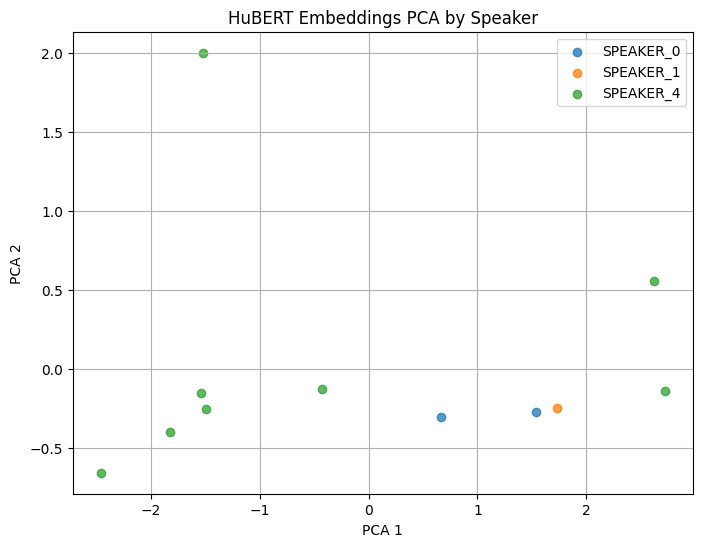

In [11]:
# =====================================================================
# شرح عربي سريع:
# تقليل أبعاد embeddings باستخدام PCA ثم رسم النقاط حسب كل speaker لفهم جودة التمثيل بصريًا.
# =====================================================================

if len(speaker_df) >= 2:
    pca = PCA(n_components=2, random_state=42)
    points = pca.fit_transform(embeddings)

    plot_df = speaker_df.copy()
    plot_df['pca_1'] = points[:, 0]
    plot_df['pca_2'] = points[:, 1]

    plt.figure(figsize=(8, 6))
    for speaker in sorted(plot_df['speaker'].unique()):
        sub = plot_df[plot_df['speaker'] == speaker]
        plt.scatter(sub['pca_1'], sub['pca_2'], label=speaker, alpha=0.75)

    plt.title('HuBERT Embeddings PCA by Speaker')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('Not enough segments for PCA visualization.')


### 11) تحميل Whisper pretrained

Whisper هنا هو الجزء المسؤول عن تحويل الكلام إلى نص.

التدفق:

```text
Audio segment → Whisper ASR → text
```

Whisper مبني على Transformer ومدرّب مسبقًا على speech-to-text. لذلك هو مختلف عن HuBERT:

- HuBERT: يعطي embeddings/features.
- Whisper: يعطي transcription/text.

يعني Whisper لا يأخذ embeddings من HuBERT في هذا النوتبوك، بل يأخذ الصوت نفسه ويطلع النص.



## 11. Load Whisper: Pretrained Transformer for Speech-to-Text

Now we use Whisper at the end.

Whisper is a **pretrained Transformer ASR model**.

```text
Audio segment → Whisper → Text
```

This is the part that converts speech into written text.


In [12]:
# =====================================================================
# شرح عربي سريع:
# تحميل Whisper ASR pipeline لتحويل المقاطع الصوتية إلى نصوص باستخدام pretrained Transformer model.
# =====================================================================

from transformers import pipeline

WHISPER_MODEL_NAME = 'openai/whisper-small'

asr = pipeline(
    task='automatic-speech-recognition',
    model=WHISPER_MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
    chunk_length_s=30,
    return_timestamps=False
)

print('Loaded:', WHISPER_MODEL_NAME)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


Loaded: openai/whisper-small


### 12) Transcription لكل speaker segment

بعد ما أصبح عندنا segments وعندنا speaker label لكل segment، ندخل الصوت على Whisper ونخزن النص الناتج مع معلومات المتحدث والزمن.

الناتج يكون جدول يحتوي على:

- `speaker`
- `start_s`
- `end_s`
- `text`
- `hubert_cluster`

وجود overlap قد يسبب تكرار بعض الكلمات بين segment والتالي. ده طبيعي ويمكن تحسينه لاحقًا بمرحلة post-processing.



## 12. Transcribe speaker segments

For demo speed, we transcribe only a limited number of segments. To transcribe everything, set:

```python
MAX_ASR_SEGMENTS = None
```

Because the segments overlap by 5 seconds, some words may appear in two neighboring segments. This is normal and can be cleaned with a post-processing step later.


In [13]:
# =====================================================================
# شرح عربي سريع:
# تشغيل Whisper على segments المحددة، ثم تخزين النص مع speaker والزمن والcluster في DataFrame نهائي.
# =====================================================================

asr_df = speaker_df.copy()
if MAX_ASR_SEGMENTS is not None:
    asr_df = asr_df.head(MAX_ASR_SEGMENTS).copy()

transcript_rows = []

for _, row in tqdm(asr_df.iterrows(), total=len(asr_df), desc='Transcribing with Whisper'):
    audio_array = load_audio_segment(row['audio_path'], row['start_s'])

    result = asr({
        'array': audio_array,
        'sampling_rate': SAMPLE_RATE
    })

    transcript_rows.append({
        'meeting_id': row['meeting_id'],
        'speaker': row['speaker'],
        'hubert_cluster': int(row['hubert_cluster']),
        'start_s': row['start_s'],
        'end_s': row['end_s'],
        'text': result['text'].strip()
    })

final_transcript_df = pd.DataFrame(transcript_rows)
final_transcript_df


Transcribing with Whisper:   0%|          | 0/11 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

,meeting_id,speaker,hubert_cluster,start_s,end_s,text
0,EN2001a,SPEAKER_0,1,0.0,30.0,Does anyone want to see Steve's feedback from ...
1,EN2001a,SPEAKER_4,1,0.0,30.0,Is there much more in it than he said yesterday?
2,EN2001a,SPEAKER_0,1,25.0,55.0,of effort and duplication of effort and stuff....
3,EN2001a,SPEAKER_4,1,25.0,55.0,"Yeah, I'd say if for the prototype if it just ..."
4,EN2001a,SPEAKER_4,0,50.0,80.0,like wherever possible chunk in the stuff that...
5,EN2001a,SPEAKER_1,1,75.0,105.0,I mean if we just want to have some data for t...
6,EN2001a,SPEAKER_4,0,75.0,105.0,Just want to have some data for the user text ...
7,EN2001a,SPEAKER_4,0,100.0,130.0,I think I can do that fairly quickly because I...
8,EN2001a,SPEAKER_4,0,125.0,155.0,sure everyone understands the interface. So I ...
9,EN2001a,SPEAKER_4,0,150.0,180.0,We want to load into it and this is how everyo...


### 13) طباعة الـ final speaker-aware transcript

هذه الخلية تطبع النتيجة النهائية بالشكل المناسب للعرض:

```text
[start - end] SPEAKER_X: recognized text
```

ده هو الهدف النهائي: نص مكتوب ومعه speaker label والزمن.



## 13. Print final speaker-aware transcript

This is the final output of this notebook.


In [14]:
# =====================================================================
# شرح عربي سريع:
# طباعة transcript النهائي بترتيب زمني، بحيث يظهر كل speaker مع بداية ونهاية المقطع والنص الناتج.
# =====================================================================

for _, row in final_transcript_df.sort_values(['start_s', 'speaker']).iterrows():
    print(f'[{row["start_s"]:.1f}s - {row["end_s"]:.1f}s] {row["speaker"]}: {row["text"]}')
    print('-' * 100)


[0.0s - 30.0s] SPEAKER_0: Does anyone want to see Steve's feedback from the specification? Not really. Just what he was talking about, like duplication of effort and stuff.
----------------------------------------------------------------------------------------------------
[0.0s - 30.0s] SPEAKER_4: Is there much more in it than he said yesterday?
----------------------------------------------------------------------------------------------------
[25.0s - 55.0s] SPEAKER_0: of effort and duplication of effort and stuff. And saying that we should maybe think about having a prototype for week six, which is next week. So we should probably prioritize our packages.
----------------------------------------------------------------------------------------------------
[25.0s - 55.0s] SPEAKER_4: Yeah, I'd say if for the prototype if it just like wherever possible chunk in the stuff that we have
----------------------------------------------------------------------------------------------------
[5

### 14) حفظ النتائج

في هذه المرحلة نحفظ النتائج في ملفات يمكن رفعها أو استخدامها في التقرير:

- `hubert_speaker_segments.csv`: بيانات segments + cluster labels.
- `speaker_aware_transcript.csv`: جدول النص النهائي.
- `speaker_aware_transcript.txt`: نسخة readable من transcript.

هذه الملفات تسهّل عليك تعرض النتائج أو ترفعها مع GitHub repo.



## 14. Save results

The notebook saves:

1. Segment metadata with HuBERT cluster labels.
2. Final speaker-aware transcript.


In [15]:
# =====================================================================
# شرح عربي سريع:
# حفظ ملفات النتائج في Google Drive: segments CSV، transcript CSV، وtranscript TXT.
# =====================================================================

OUTPUT_DIR = Path('/content/drive/MyDrive/AMI_Project_Outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

segments_output_path = OUTPUT_DIR / 'hubert_speaker_segments.csv'
transcript_output_path = OUTPUT_DIR / 'speaker_aware_transcript.csv'
text_output_path = OUTPUT_DIR / 'speaker_aware_transcript.txt'

speaker_df.to_csv(segments_output_path, index=False)
final_transcript_df.to_csv(transcript_output_path, index=False)

with open(text_output_path, 'w', encoding='utf-8') as f:
    for _, row in final_transcript_df.sort_values(['start_s', 'speaker']).iterrows():
        f.write(f'[{row["start_s"]:.1f}s - {row["end_s"]:.1f}s] {row["speaker"]}: {row["text"]}\n')

print('Saved segment file:', segments_output_path)
print('Saved transcript CSV:', transcript_output_path)
print('Saved transcript TXT:', text_output_path)


Saved segment file: /content/drive/MyDrive/AMI_Project_Outputs/hubert_speaker_segments.csv
Saved transcript CSV: /content/drive/MyDrive/AMI_Project_Outputs/speaker_aware_transcript.csv
Saved transcript TXT: /content/drive/MyDrive/AMI_Project_Outputs/speaker_aware_transcript.txt


### 15) كلام مختصر للعرض

القسم الأخير يحتوي على صياغة جاهزة تقولها للدكتور أو تضعها في README. أهم نقطة لا تقول إنك fine-tuned HuBERT أو Whisper إلا لو فعلًا عملت training لأوزان الموديل.

الصحيح:

```text
I used pretrained HuBERT for feature extraction and pretrained Whisper for ASR inference.
```



## 15. What to say in the presentation

Use this explanation:

```text
My part uses pretrained models instead of training everything from scratch.

First, I use the same preprocessing idea: each headset audio file is divided into 30-second windows, and each next window starts at 25 seconds, giving a 5-second overlap.

Then, I use pretrained HuBERT to extract deep speech embeddings from every audio window. These embeddings represent the speaker and acoustic characteristics of the segment.

After that, I use KMeans clustering to show that HuBERT embeddings can group speaker segments.

Finally, I use Whisper, which is a pretrained Transformer-based ASR model, to convert each speaker segment into text.

The final output is a speaker-aware transcript: each line contains the speaker label and the recognized text.
```

## Difference between this notebook and the scratch notebook

| Step | Scratch notebook | This notebook |
|---|---|---|
| Segmentation | Sliding windows | 30s window, 25s hop |
| Features | Log-Mel spectrogram | Pretrained HuBERT embeddings |
| Speaker modeling | CNN + Transformer from scratch | HuBERT embeddings + KMeans |
| Speech-to-text | Not the main goal | Whisper pretrained Transformer |
| Final output | Speaker diarization accuracy | Speaker-aware transcript |

## Important note about fine-tuning

This notebook uses pretrained models for inference / feature extraction.

Do not say:

```text
I fine-tuned HuBERT or Whisper.
```

unless you actually train their weights.

Say instead:

```text
I used pretrained HuBERT for feature extraction and Whisper for speech-to-text inference.
```
